This is an example of a simple CNN developed, trained and utilized

AI was used to help generate the codebase

Note: Make sure that the tensorflow package is installed in your device.

In [1]:
# Lib imports
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import numpy as np

In [2]:
# DATASET DIRECTORY CONFIGURATION
# Download and unzip the dataset from Kaggle, set the directory paths accordingly.
train_dir = "train"  # Changed from "train_1" to match your actual folder
test_dir = "test"    # Changed from "test_1" to match your actual folder

In [3]:
# IMAGE PARAMETERS
# Used to resize the input images, also will determine the input size of your input layer.
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

In [4]:
# DATA PREPROCESSING & AUGMENTATION
# Optional but recommended for image processing tasks, especially with limited data.
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.


In [5]:
# Check class indices to understand the model's labels
print("Class indices:", train_generator.class_indices)
print("This tells us which class is 0 and which is 1")

Class indices: {'chihuahua': 0, 'muffin': 1}
This tells us which class is 0 and which is 1


In [6]:
# IMPROVED CNN MODEL ARCHITECTURE WITH REGULARIZATION AND DROPOUT

# Some modifications are applied
initial_learning_rate = 0.001
# We are combining ExponentialDecay with Adam optimizer for better learning rate management
lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True
)

# Create the optimizer with the learning rate schedule
optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule)

# Applied dropout layers to reduce overfitting and L2 regularization
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', 
                  kernel_regularizer=tf.keras.regularizers.l2(0.001),
                  input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

c:\Users\Frederick Jibril\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# Configure the model optimizers, loss function, and metrics
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']) # old
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

In [8]:
# TRAINING THE CNN
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 98s 810ms/step - accuracy: 0.6497 - loss: 0.9123 - val_accuracy: 0.7460 - val_loss: 0.6967
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 98s 810ms/step - accuracy: 0.6497 - loss: 0.9123 - val_accuracy: 0.7460 - val_loss: 0.6967
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 289ms/step - accuracy: 0.7870 - loss: 0.6323 - val_accuracy: 0.8307 - val_loss: 0.5418
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 34s 289ms/step - accuracy: 0.7870 - loss: 0.6323 - val_accuracy: 0.8307 - val_loss: 0.5418
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 38s 316ms/step - accuracy: 0.8068 - loss: 0.5530 - val_accuracy: 0.8497 - val_loss: 0.4642
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 38s 316ms/step - accuracy: 0.8068 - loss: 0.5530 - val_accuracy: 0.8497 - val_loss: 0.4642
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 40s 338ms/step - accuracy: 0.8134 - loss: 0.5187 - val_accuracy: 0.8529 - val_loss: 0.4561
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 40s 338ms/step - accuracy: 0.8134 - loss: 0

In [9]:
# EVALUATE THE MODEL
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc}")

37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 379ms/step - accuracy: 0.8294 - loss: 0.4554
Test Accuracy: 0.8293918967247009
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 379ms/step - accuracy: 0.8294 - loss: 0.4554
Test Accuracy: 0.8293918967247009


In [10]:
# SAVE THE MODEL
model.save('exercise_6_trained_model_improved.h5')  # Saved as requested filename

In [11]:
# SIMPLE INFERENCE SCRIPT (FIXED)
from tensorflow.keras.preprocessing import image

def predict_image(img_path, model_path='exercise_6_trained_model_improved.h5'):
    model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)[0,0]
    
    # Based on alphabetical order: chihuahua=0, muffin=1
    # Lower values (< 0.5) = Chihuahua, Higher values (>= 0.5) = Muffin
    label = "Muffin" if pred >= 0.5 else "Chihuahua"
    confidence = pred if pred >= 0.5 else (1 - pred)
    
    print(f"Prediction: {label} (confidence: {confidence:.2f})")
    print(f"Raw prediction value: {pred:.4f}")

In [12]:
# Example usage - Run 1 and Run 2 predictions:
print("=== Run 1 ===")
predict_image("test/chihuahua/img_0_5.jpg")
print("\n=== Run 2 ===")
predict_image("test/chihuahua/img_0_8.jpg")

=== Run 1 ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


Prediction: Chihuahua (confidence: 0.80)
Raw prediction value: 0.1968

=== Run 2 ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Chihuahua (confidence: 0.63)
Raw prediction value: 0.3682
Prediction: Chihuahua (confidence: 0.63)
Raw prediction value: 0.3682


---

# Number 3: Custom Dataset CNN

In [13]:
# CUSTOM DATASET CONFIGURATION - CAT VS DOG
custom_train_dir = "custom_train"  # Contains cat/ and dog/ folders
custom_test_dir = "custom_test"    # Contains cat/ and dog/ folders

# Hyperparameters
CUSTOM_IMG_SIZE = (128, 128)
CUSTOM_BATCH_SIZE = 32
CUSTOM_EPOCHS = 15

In [14]:
# DATA PREPROCESSING & AUGMENTATION FOR CUSTOM DATASET
custom_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,
    validation_split=0.2
)
custom_test_datagen = ImageDataGenerator(rescale=1./255)

custom_train_generator = custom_train_datagen.flow_from_directory(
    custom_train_dir,
    target_size=CUSTOM_IMG_SIZE,
    batch_size=CUSTOM_BATCH_SIZE,
    class_mode='binary',
    subset='training'
)
custom_val_generator = custom_train_datagen.flow_from_directory(
    custom_train_dir,
    target_size=CUSTOM_IMG_SIZE,
    batch_size=CUSTOM_BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)
custom_test_generator = custom_test_datagen.flow_from_directory(
    custom_test_dir,
    target_size=CUSTOM_IMG_SIZE,
    batch_size=CUSTOM_BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Display dataset information
print("Custom Dataset Information:")
print(f"Class indices: {custom_train_generator.class_indices}")
print(f"Training samples: {custom_train_generator.samples}")
print(f"Validation samples: {custom_val_generator.samples}")
print(f"Test samples: {custom_test_generator.samples}")

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Custom Dataset Information:
Class indices: {'cat': 0, 'dog': 1}
Training samples: 800
Validation samples: 200
Test samples: 1000
Found 1000 images belonging to 2 classes.
Custom Dataset Information:
Class indices: {'cat': 0, 'dog': 1}
Training samples: 800
Validation samples: 200
Test samples: 1000


In [15]:
# BUILD CUSTOM CNN MODEL (Same architecture as improved model)
custom_lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
    0.001,
    decay_steps=10000,
    decay_rate=0.9,
    staircase=True
)

custom_optimizer = tf.keras.optimizers.Adam(learning_rate=custom_lr_schedule)

custom_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', 
                  kernel_regularizer=tf.keras.regularizers.l2(0.001),
                  input_shape=(CUSTOM_IMG_SIZE[0], CUSTOM_IMG_SIZE[1], 3)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    
    layers.Conv2D(64, (3, 3), activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    
    layers.Conv2D(128, (3, 3), activation='relu',
                  kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

custom_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# COMPILE CUSTOM MODEL
custom_model.compile(
    optimizer=custom_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [17]:
# TRAIN CUSTOM MODEL
print("Training custom CNN model...")
custom_history = custom_model.fit(
    custom_train_generator,
    epochs=CUSTOM_EPOCHS,
    validation_data=custom_val_generator
)

Training custom CNN model...
Epoch 1/15
Epoch 1/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 560ms/step - accuracy: 0.5387 - loss: 1.0569 - val_accuracy: 0.6000 - val_loss: 0.9592
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 560ms/step - accuracy: 0.5387 - loss: 1.0569 - val_accuracy: 0.6000 - val_loss: 0.9592
Epoch 2/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 483ms/step - accuracy: 0.6388 - loss: 0.8984 - val_accuracy: 0.6550 - val_loss: 0.8377
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 12s 483ms/step - accuracy: 0.6388 - loss: 0.8984 - val_accuracy: 0.6550 - val_loss: 0.8377
Epoch 3/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 660ms/step - accuracy: 0.6263 - loss: 0.8402 - val_accuracy: 0.6400 - val_loss: 0.7979
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 16s 660ms/step - accuracy: 0.6263 - loss: 0.8402 - val_accuracy: 0.6400 - val_loss: 0.7979
Epoch 4/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 688ms/step - accuracy: 0.6625 - loss: 0.7738 - val_accuracy: 0.6850 - val_loss: 0.7952
Epoch 5/15
25/25 ━━━━━━━━━━━━━━━━━━━━ 17s 688ms/step - ac

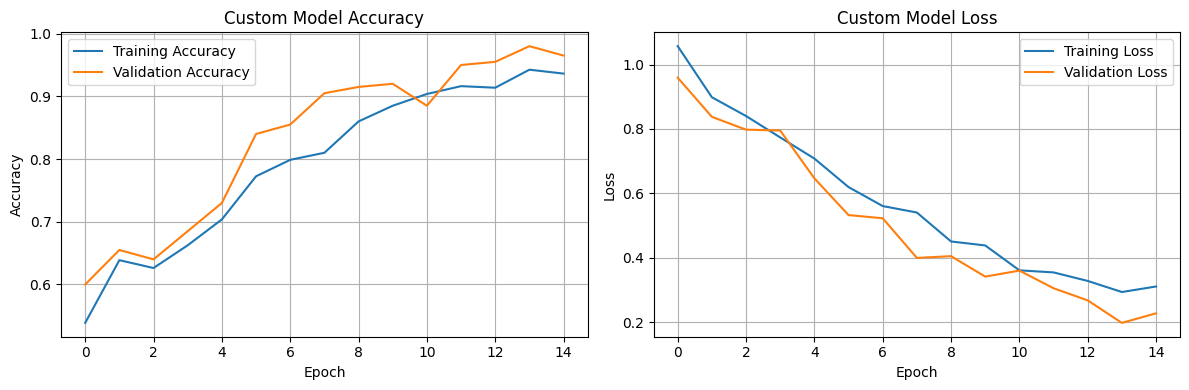

In [18]:
# VISUALIZE TRAINING HISTORY
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(custom_history.history['accuracy'], label='Training Accuracy')
plt.plot(custom_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Custom Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(custom_history.history['loss'], label='Training Loss')
plt.plot(custom_history.history['val_loss'], label='Validation Loss')
plt.title('Custom Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [19]:
# EVALUATE CUSTOM MODEL
custom_test_loss, custom_test_acc = custom_model.evaluate(custom_test_generator)
print(f"\nCustom Model Results:")
print(f"Test Accuracy: {custom_test_acc:.4f}")
print(f"Test Loss: {custom_test_loss:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.9730 - loss: 0.1967

Custom Model Results:
Test Accuracy: 0.9730
Test Loss: 0.1967
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 264ms/step - accuracy: 0.9730 - loss: 0.1967

Custom Model Results:
Test Accuracy: 0.9730
Test Loss: 0.1967


In [20]:
# SAVE CUSTOM MODEL
custom_model.save('exercise_6_custom_bunag.h5')
print("Custom model saved as 'exercise_6_custom_bunag.h5'")

Custom model saved as 'exercise_6_custom_bunag.h5'


In [21]:
# CUSTOM MODEL INFERENCE FUNCTION
def predict_custom_image(img_path, model_path='exercise_6_custom_bunag.h5'):
    """
    Predict the class of an image using the custom trained model.
    """
    loaded_model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=CUSTOM_IMG_SIZE)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = loaded_model.predict(img_array)[0,0]
    
    # Get class names from custom dataset (alphabetically ordered)
    class_names = list(custom_train_generator.class_indices.keys())
    
    # Lower values (< 0.5) = class 0, Higher values (>= 0.5) = class 1
    label = class_names[1] if pred >= 0.5 else class_names[0]
    confidence = pred if pred >= 0.5 else (1 - pred)
    
    print(f"Prediction: {label} (confidence: {confidence:.2f})")
    print(f"Raw prediction value: {pred:.4f}")
    
    return label, confidence

In [22]:
# TEST CUSTOM MODEL PREDICTIONS - CAT VS DOG
# Testing with sample images from the dataset
print("=== Cat vs Dog Test 1 - Cat Image ===")
predict_custom_image("custom_test/cat/00000-4122619873.png")

print("\n=== Cat vs Dog Test 2 - Dog Image ===")
predict_custom_image("custom_test/dog/00500-3846168662.png")

=== Cat vs Dog Test 1 - Cat Image ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step


Prediction: cat (confidence: 0.95)
Raw prediction value: 0.0503

=== Cat vs Dog Test 2 - Dog Image ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Prediction: dog (confidence: 0.96)
Raw prediction value: 0.9567
Prediction: dog (confidence: 0.96)
Raw prediction value: 0.9567


('dog', np.float32(0.9567183))

---

# Part 4: ResNet Architecture - Muffin vs Chihuahua

## Using Pre-trained ResNet50 with Transfer Learning

**Transfer Learning Approach:**
- Load pre-trained ResNet50 (trained on ImageNet)
- Freeze base layers to retain learned features
- Add custom classification layers for binary classification
- Fine-tune on the muffin vs chihuahua dataset

**Why ResNet?**
- ResNet (Residual Networks) uses skip connections to solve vanishing gradient problem
- Deeper networks (50+ layers) without degradation
- Pre-trained on ImageNet provides excellent feature extraction
- Better than simple CNN for complex image classification

In [23]:
# IMPORT RESNET50 FROM KERAS APPLICATIONS
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

In [24]:
# RESNET CONFIGURATION
RESNET_IMG_SIZE = (224, 224)  # ResNet expects 224x224 input
RESNET_BATCH_SIZE = 32
RESNET_EPOCHS = 10

# Use the original muffin vs chihuahua dataset
resnet_train_dir = train_dir
resnet_test_dir = test_dir

In [26]:
# DATA PREPROCESSING FOR RESNET
# ResNet uses its own preprocessing function
resnet_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)
resnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

resnet_train_generator = resnet_train_datagen.flow_from_directory(
    resnet_train_dir,
    target_size=RESNET_IMG_SIZE,
    batch_size=RESNET_BATCH_SIZE,
    class_mode='binary',
    subset='training'
)
resnet_val_generator = resnet_train_datagen.flow_from_directory(
    resnet_train_dir,
    target_size=RESNET_IMG_SIZE,
    batch_size=RESNET_BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)
resnet_test_generator = resnet_test_datagen.flow_from_directory(
    resnet_test_dir,
    target_size=RESNET_IMG_SIZE,
    batch_size=RESNET_BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("ResNet Data Generators:")
print(f"Class indices: {resnet_train_generator.class_indices}")
print(f"Training samples: {resnet_train_generator.samples}")
print(f"Validation samples: {resnet_val_generator.samples}")
print(f"Test samples: {resnet_test_generator.samples}")

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.
Found 1184 images belonging to 2 classes.
ResNet Data Generators:
Class indices: {'chihuahua': 0, 'muffin': 1}
Training samples: 3788
Validation samples: 945
Test samples: 1184


In [27]:
# BUILD RESNET50 MODEL WITH TRANSFER LEARNING
# Load pre-trained ResNet50 (without top classification layer)
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(RESNET_IMG_SIZE[0], RESNET_IMG_SIZE[1], 3)
)

# Freeze the base model layers (don't train pre-trained weights initially)
base_model.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.5)(x)
x = Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = layers.Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

# Create the final model
resnet_model = Model(inputs=base_model.input, outputs=predictions)

print("ResNet50 Model Architecture:")
print(f"Total layers: {len(resnet_model.layers)}")
print(f"Trainable layers: {sum([layer.trainable for layer in resnet_model.layers])}")
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
ResNet50 Model Architecture:
Total layers: 181
Trainable layers: 6


Model: "functional_54"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
# COMPILE RESNET MODEL
resnet_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

resnet_model.compile(
    optimizer=resnet_optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("ResNet model compiled successfully!")

ResNet model compiled successfully!


In [29]:
# TRAIN RESNET MODEL
print("Training ResNet50 model on Muffin vs Chihuahua dataset...")
print("This may take longer than the simple CNN due to the larger architecture.")

resnet_history = resnet_model.fit(
    resnet_train_generator,
    epochs=RESNET_EPOCHS,
    validation_data=resnet_val_generator
)

print("\nTraining completed!")

Training ResNet50 model on Muffin vs Chihuahua dataset...
This may take longer than the simple CNN due to the larger architecture.
Epoch 1/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 186s 2s/step - accuracy: 0.9142 - loss: 0.8219 - val_accuracy: 0.9905 - val_loss: 0.6541
Epoch 2/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.9828 - loss: 0.6601 - val_accuracy: 0.9905 - val_loss: 0.6226
Epoch 3/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9850 - loss: 0.6193 - val_accuracy: 0.9926 - val_loss: 0.6008
Epoch 4/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 174s 1s/step - accuracy: 0.9908 - loss: 0.5884 - val_accuracy: 0.9905 - val_loss: 0.5789
Epoch 5/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 170s 1s/step - accuracy: 0.9926 - loss: 0.5613 - val_accuracy: 0.9905 - val_loss: 0.5580
Epoch 6/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - accuracy: 0.9947 - loss: 0.5296 - val_accuracy: 0.9937 - val_loss: 0.5280
Epoch 7/10
119/119 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.9916 - loss: 0.5100 - val_ac

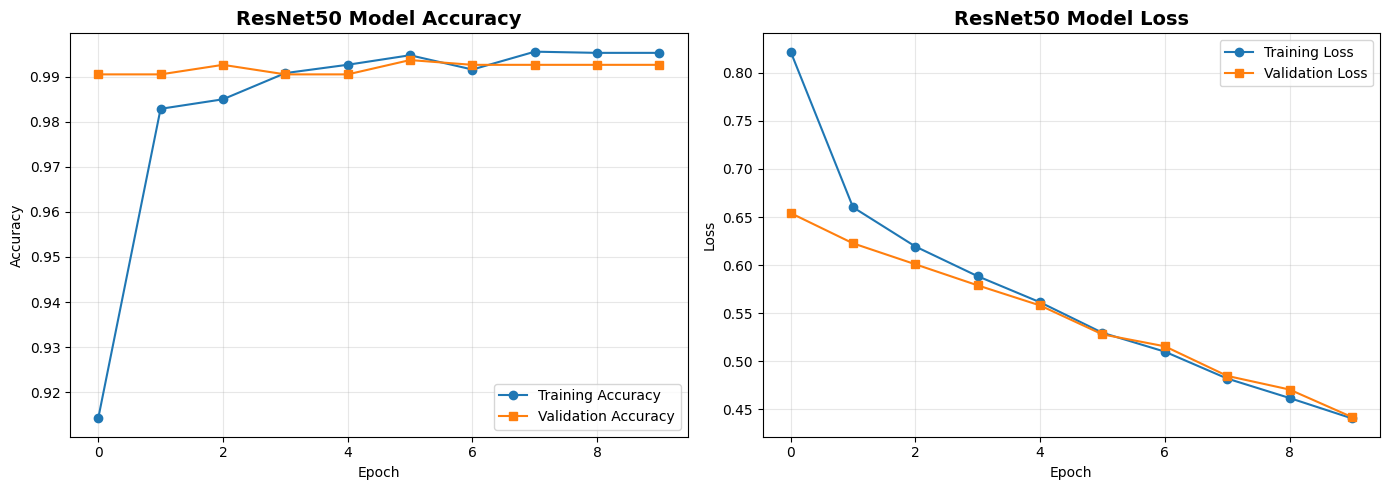


Final Training Accuracy: 0.9952
Final Validation Accuracy: 0.9926


In [30]:
# VISUALIZE RESNET TRAINING HISTORY
plt.figure(figsize=(14, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(resnet_history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(resnet_history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('ResNet50 Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(resnet_history.history['loss'], label='Training Loss', marker='o')
plt.plot(resnet_history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('ResNet50 Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
final_train_acc = resnet_history.history['accuracy'][-1]
final_val_acc = resnet_history.history['val_accuracy'][-1]
print(f"\nFinal Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

In [31]:
# EVALUATE RESNET MODEL ON TEST SET
print("Evaluating ResNet50 model on test data...")
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(resnet_test_generator)

print(f"\n{'='*50}")
print(f"RESNET50 TEST RESULTS")
print(f"{'='*50}")
print(f"Test Accuracy: {resnet_test_acc:.4f} ({resnet_test_acc*100:.2f}%)")
print(f"Test Loss: {resnet_test_loss:.4f}")
print(f"{'='*50}")

Evaluating ResNet50 model on test data...
37/37 ━━━━━━━━━━━━━━━━━━━━ 37s 997ms/step - accuracy: 0.9907 - loss: 0.4425

RESNET50 TEST RESULTS
Test Accuracy: 0.9907 (99.07%)
Test Loss: 0.4425


In [32]:
# SAVE RESNET MODEL
resnet_model.save('exercise_6_resnet_bunag.h5')
print("ResNet50 model saved as 'exercise_6_resnet_bunag.h5'")

ResNet50 model saved as 'exercise_6_resnet_bunag.h5'


In [33]:
# RESNET INFERENCE FUNCTION
def predict_with_resnet(img_path, model_path='exercise_6_resnet_bunag.h5'):
    """
    Predict muffin vs chihuahua using the ResNet50 model.
    """
    loaded_model = tf.keras.models.load_model(model_path)
    img = image.load_img(img_path, target_size=RESNET_IMG_SIZE)
    img_array = image.img_to_array(img)
    img_array = preprocess_input(img_array)  # Use ResNet preprocessing
    img_array = np.expand_dims(img_array, axis=0)
    pred = loaded_model.predict(img_array)[0,0]
    
    # Class indices: chihuahua=0, muffin=1 (alphabetically)
    label = "Muffin" if pred >= 0.5 else "Chihuahua"
    confidence = pred if pred >= 0.5 else (1 - pred)
    
    print(f"Prediction: {label} (confidence: {confidence:.2f})")
    print(f"Raw prediction value: {pred:.4f}")
    
    return label, confidence

In [34]:
# TEST RESNET PREDICTIONS ON SAME IMAGES
print("=== ResNet Test 1 - Chihuahua Image ===")
predict_with_resnet("test/chihuahua/img_0_5.jpg")

print("\n=== ResNet Test 2 - Chihuahua Image ===")
predict_with_resnet("test/chihuahua/img_0_8.jpg")

=== ResNet Test 1 - Chihuahua Image ===


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Chihuahua (confidence: 1.00)
Raw prediction value: 0.0009

=== ResNet Test 2 - Chihuahua Image ===


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Prediction: Chihuahua (confidence: 1.00)
Raw prediction value: 0.0000


('Chihuahua', np.float32(0.99996513))